In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import seaborn as sns

In [25]:
Data = cifar10.load_data()
Data

((xTrain,yTrain),(xTest,yTest)) = Data

c:\Users\hamza\OneDrive\Documents\Deep_Learning_JL\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [26]:
Animal, Vehicle = [2,3,4,5,6,7],[0,1,8,9]
yTrain = yTrain.flatten()
for i in range(len(yTrain)):
    if yTrain[i] in Animal:
        yTrain[i] = 0
    else:
        yTrain[i] = 1

In [27]:
yTest = yTest.flatten()
for i in range(len(yTest)):
    if yTest[i] in Animal:
        yTest[i] = 0
    else:
        yTest[i] = 1

In [28]:
print(yTrain)
#yTrain = to_categorical(yTrain, 2).astype(int)

[0 1 1 ... 1 1 1]


In [29]:
xTrain = xTrain/255
xTest = xTest/255

In [30]:
xTrain

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [31]:
yTrain.shape

(50000,)

In [32]:
model = Sequential()
#layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

c:\Users\hamza\OneDrive\Documents\Deep_Learning_JL\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(xTrain, yTrain, epochs=10, validation_data=(xTest, yTest), batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8819 - loss: 0.2852 - val_accuracy: 0.9092 - val_loss: 0.2252
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9120 - loss: 0.2219 - val_accuracy: 0.9099 - val_loss: 0.2149
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.9228 - loss: 0.1956 - val_accuracy: 0.9233 - val_loss: 0.1873
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9299 - loss: 0.1779 - val_accuracy: 0.9141 - val_loss: 0.2132
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.9375 - loss: 0.1601 - val_accuracy: 0.9301 - val_loss: 0.1797
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9432 - loss: 0.1435 - val_accuracy: 0.9277 - val_loss: 0.1795
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.9497 - loss: 0.1306 - val_accuracy: 0.9298 - val_loss: 0.1868
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.9553 -

In [34]:
model.save("Cool_CNN.h5")

In [ ]:
#model = load_model("Cool_CNN.h5")

In [35]:
y_pred_probs = model.predict(xTest)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [36]:
cm = confusion_matrix(yTest, y_pred)
print(cm)

[[5752  248]
 [ 432 3568]]


In [ ]:
acc_score = accuracy_score(yTest, y_pred)
acc_score*100

0.932

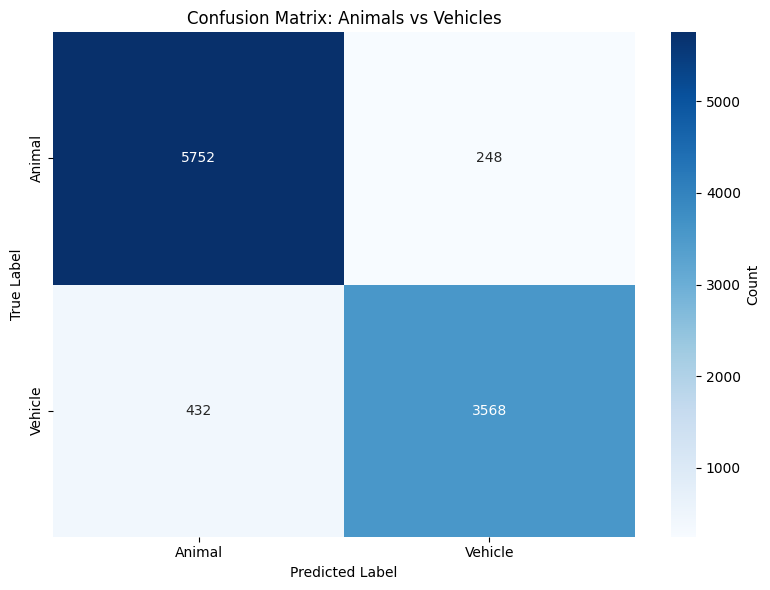

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Animal', 'Vehicle'], yticklabels=['Animal', 'Vehicle'], cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Animals vs Vehicles')
plt.tight_layout()
plt.show()

In [65]:
misclassified_indices = np.where(y_pred != yTest)[0]
print(f'Total misclassified: {len(misclassified_indices)} out of {len(yTest)}')

Total misclassified: 680 out of 10000


In [39]:
cifar10_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Animal_list = [2,3,4,5,6,7]
Vehicle_list = [0,1,8,9]

In [40]:
num_to_display = 5
selected_indices = misclassified_indices[:num_to_display]

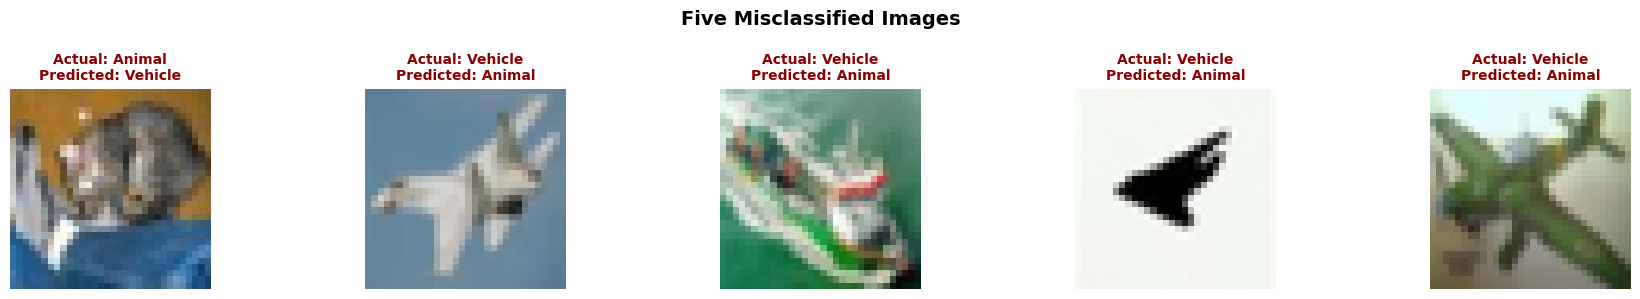

In [41]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle('Five Misclassified Images', fontsize=14, fontweight='bold')

for idx, (ax, img_idx) in enumerate(zip(axes, selected_indices)):
    image = xTest[img_idx]
    true_label = yTest[img_idx]
    pred_label = y_pred[img_idx]
    true_name = 'Animal' if true_label == 0 else 'Vehicle'
    pred_name = 'Animal' if pred_label == 0 else 'Vehicle'
    
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f'Actual: {true_name}\nPredicted: {pred_name}', fontsize=10, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
y_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(10000,))

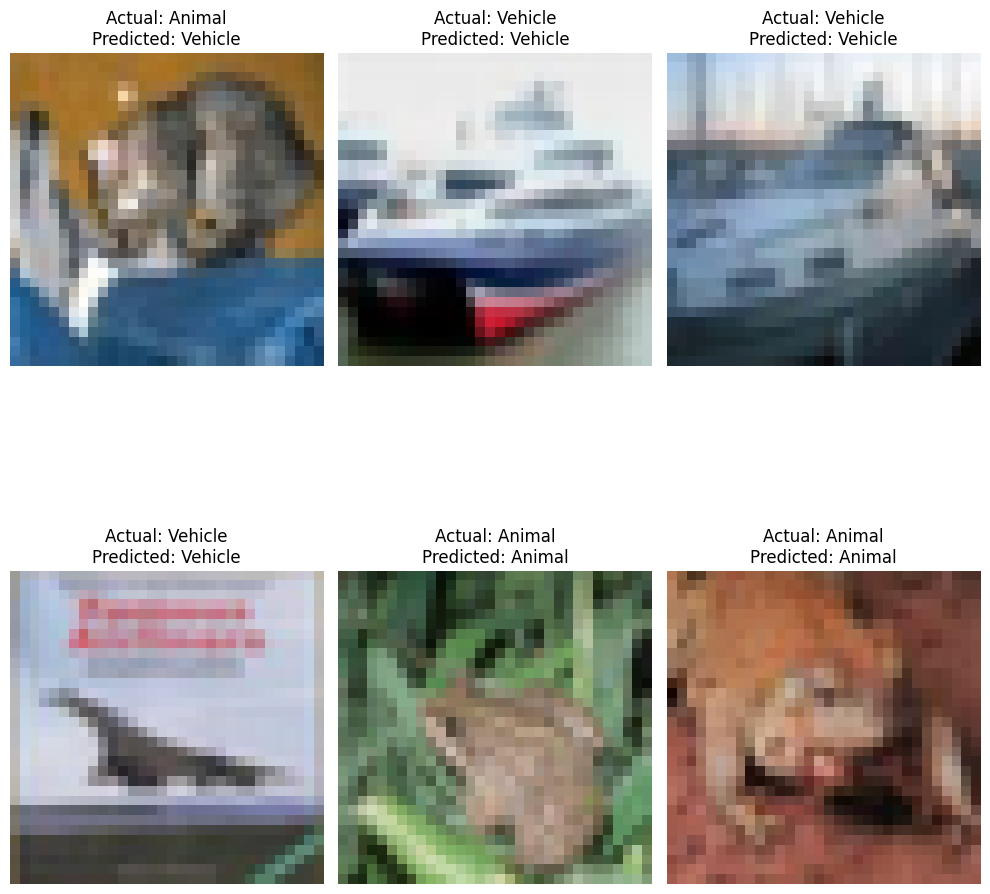

In [64]:
plt.figure(figsize=(10,12))
for i in range(0,6):
    plt.subplot(2,3,i+1)
    plt.axis("off")
    plt.imshow(xTest[i])
    plt.title(f"Actual: {"Animal" if yTest[i]==0 else "Vehicle"}\nPredicted: {"Animal" if y_pred[i]==0 else "Vehicle"}")
plt.tight_layout()
plt.show()

In [42]:
misclassified_images_data = []

for img_idx in selected_indices:
    image = xTest[img_idx]
    true_label = yTest[img_idx]
    pred_label = y_pred[img_idx]
    true_category = 'Animal' if true_label == 0 else 'Vehicle'
    pred_category = 'Animal' if pred_label == 0 else 'Vehicle'
    
    brightness = np.mean(image)
    contrast = np.std(image)
    color_variance = np.var(image)
    confidence = y_pred_probs[img_idx][pred_label]
    
    misclassified_images_data.append({
        'image': image,
        'actual': true_category,
        'predicted': pred_category,
        'brightness': brightness,
        'contrast': contrast,
        'color_variance': color_variance,
        'confidence': confidence
    })

In [43]:
print('Misclassified Images Analysis:')
print('='*70)

for i, data in enumerate(misclassified_images_data, 1):
    print(f'\nImage {i}:')
    print(f'  Actual: {data["actual"]} | Predicted: {data["predicted"]} | Confidence: {data["confidence"]:.4f}')
    print(f'  Brightness: {data["brightness"]:.3f}')
    print(f'  Contrast: {data["contrast"]:.3f}')
    print(f'  Color Variance: {data["color_variance"]:.4f}')

Misclassified Images Analysis:

Image 1:
  Actual: Animal | Predicted: Vehicle | Confidence: 0.5101
  Brightness: 0.425
  Contrast: 0.183
  Color Variance: 0.0335

Image 2:
  Actual: Vehicle | Predicted: Animal | Confidence: 0.6568
  Brightness: 0.550
  Contrast: 0.122
  Color Variance: 0.0149

Image 3:
  Actual: Vehicle | Predicted: Animal | Confidence: 0.5708
  Brightness: 0.499
  Contrast: 0.210
  Color Variance: 0.0441

Image 4:
  Actual: Vehicle | Predicted: Animal | Confidence: 0.9394
  Brightness: 0.852
  Contrast: 0.274
  Color Variance: 0.0750

Image 5:
  Actual: Vehicle | Predicted: Animal | Confidence: 0.6884
  Brightness: 0.528
  Contrast: 0.238
  Color Variance: 0.0566


In [44]:
print('\nCommon Features in Misclassified Images:')
print('='*70)

avg_brightness = np.mean([d['brightness'] for d in misclassified_images_data])
avg_contrast = np.mean([d['contrast'] for d in misclassified_images_data])
avg_color_var = np.mean([d['color_variance'] for d in misclassified_images_data])
avg_confidence = np.mean([d['confidence'] for d in misclassified_images_data])

print(f'Avg Brightness: {avg_brightness:.4f}')
print(f'Avg Contrast: {avg_contrast:.4f}')
print(f'Avg Color Variance: {avg_color_var:.4f}')
print(f'Avg Confidence: {avg_confidence:.4f}')


Common Features in Misclassified Images:
Avg Brightness: 0.5708
Avg Contrast: 0.2054
Avg Color Variance: 0.0448
Avg Confidence: 0.6731


In [45]:
correct_indices = np.where(y_pred == yTest)[0]
correct_confidences = np.max(y_pred_probs[correct_indices], axis=1)

misclass_confidences = np.max(y_pred_probs[misclassified_indices], axis=1)

print(f'\nConfidence Comparison:')
print(f'Correctly Classified Average Confidence: {np.mean(correct_confidences):.4f}')
print(f'Misclassified Average Confidence: {np.mean(misclass_confidences):.4f}')
print(f'Difference: {np.mean(correct_confidences) - np.mean(misclass_confidences):.4f}')


Confidence Comparison:
Correctly Classified Average Confidence: 0.9706
Misclassified Average Confidence: 0.8082
Difference: 0.1624


In [46]:
animal_to_vehicle = np.sum((yTest == 0) & (y_pred == 1))
vehicle_to_animal = np.sum((yTest == 1) & (y_pred == 0))

print(f'\nMisclassification Direction:')
print(f'Animals wrongly as Vehicles: {animal_to_vehicle}')
print(f'Vehicles wrongly as Animals: {vehicle_to_animal}')


Misclassification Direction:
Animals wrongly as Vehicles: 248
Vehicles wrongly as Animals: 432


In [47]:
print('\n' + '='*70)
print('RECOMMENDED IMPROVEMENT: DATA AUGMENTATION')
print('='*70)

recommendation = """
Problem...
- Model has low confidence on images with low contrast and brightness
- Model full of images in the same lighting and orientation
- Lacks diversity

Solution :)
- Just increase training data diversity
- Apply random rotations, brightness changes, zoom, flips
- More unique vairations
"""

print(recommendation)


RECOMMENDED IMPROVEMENT: DATA AUGMENTATION

Problem...
- Model has low confidence on images with low contrast and brightness
- Model full of images in the same lighting and orientation
- Lacks diversity

Solution :)
- Just increase training data diversity
- Apply random rotations, brightness changes, zoom, flips
- More unique vairations



In [48]:
print('Oh yea heres the report lol')
print(classification_report(yTest, y_pred, target_names=['Animal', 'Vehicle']))

Oh yea heres the report lol
              precision    recall  f1-score   support

      Animal       0.93      0.96      0.94      6000
     Vehicle       0.94      0.89      0.91      4000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

